# Ames Housing — Notebook 2 

> **Objectif** : Améliorer le score Kaggle obtenu avec ElasticNet (Notebook 1) en utilisant des modèles plus puissants et un tuning intelligent des hyperparamètres.

On ne refait pas l'EDA — elle est déjà faite dans le Notebook 1. On repart du preprocessing et on va droit au but.

---

## 1. Chargement & Preprocessing

On reproduit exactement les mêmes étapes que dans le Notebook 1 — même nettoyage, même feature engineering, même pipeline. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Chargement
df_train = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
df_test  = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')

# ── Valeurs manquantes catégorielles → 'None'
cols_fillna = ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu',
               'GarageQual','GarageCond','GarageFinish','GarageType','Electrical',
               'KitchenQual','SaleType','Functional','Exterior2nd','Exterior1st',
               'BsmtExposure','BsmtCond','BsmtQual','BsmtFinType1','BsmtFinType2',
               'MSZoning','Utilities']
for col in cols_fillna:
    df_train[col] = df_train[col].fillna('None')
    df_test[col]  = df_test[col].fillna('None')

# ── Valeurs manquantes numériques → moyenne
means = df_train.mean(numeric_only=True)
for col in means.index:
    df_train[col] = df_train[col].fillna(means[col])

# ── Transformation log de la cible
df_train['log_SalePrice'] = np.log1p(df_train['SalePrice'])

# ── Suppression Id
df_train = df_train.drop(columns=['Id'])

# ── Suppression des 2 outliers extrêmes
mask = ~((df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300_000))
df_clean = df_train[mask].copy()

# ── Feature Engineering
df_clean['HouseAge']        = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['YearsSinceRemod'] = df_clean['YrSold'] - df_clean['YearRemodAdd']
df_clean['TotalSF']         = df_clean['GrLivArea'] + df_clean['TotalBsmtSF']
df_clean['TotalBath']       = (df_clean['FullBath'] + 0.5*df_clean['HalfBath']
                               + df_clean['BsmtFullBath'] + 0.5*df_clean['BsmtHalfBath'])
df_clean['HasPool']         = (df_clean['PoolArea'] > 0).astype(int)
df_clean['HasGarage']       = (df_clean['GarageArea'] > 0).astype(int)
df_clean['Has2ndFloor']     = (df_clean['2ndFlrSF'] > 0).astype(int)
df_clean['HasBsmt']         = (df_clean['TotalBsmtSF'] > 0).astype(int)

# ── Séparation features / cible
y = df_clean['log_SalePrice'].copy()
cols_to_drop = ['SalePrice','log_SalePrice','GarageArea','1stFlrSF',
                'TotRmsAbvGrd','Street','Utilities']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
X = df_clean.drop(columns=cols_to_drop)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# ── Pipeline preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')

# ── Split 80/20
y_deciles = pd.qcut(y, q=10, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_deciles
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Preprocessing terminé")
print(f"   X_train : {X_train.shape} | X_test : {X_test.shape}")


Preprocessing terminé
   X_train : (1166, 82) | X_test : (292, 82)


En une seule cellule, on a reproduit tout le travail de nettoyage du Notebook 1. Les données sont propres, les nouvelles features sont créées, et le pipeline est prêt. 

---
## 2. XGBoost


In [2]:
from xgboost import XGBRegressor

# ── Définition du modèle XGBoost dans un pipeline complet
xgb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', XGBRegressor(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 4,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        random_state    = 42,
        n_jobs          = -1,
        verbosity       = 0
    ))
])

# ── Validation croisée 5-Fold
xgb_scores = cross_val_score(
    xgb_pipeline, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
xgb_rmse_cv = -xgb_scores.mean()
xgb_rmse_std = xgb_scores.std()

print(f"XGBoost — RMSE CV : {xgb_rmse_cv:.5f} (± {xgb_rmse_std:.5f})")

# ── Entraînement final et évaluation sur le test set
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb  = xgb_pipeline.predict(X_test)
xgb_rmse    = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2      = r2_score(y_test, y_pred_xgb)
xgb_mape    = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_xgb)) / np.expm1(y_test))) * 100

print(f"XGBoost — RMSE Test : {xgb_rmse:.5f} | R² : {xgb_r2:.4f} | MAPE : {xgb_mape:.2f}%")


XGBoost — RMSE CV : 0.12364 (± 0.01155)
XGBoost — RMSE Test : 0.11439 | R² : 0.9220 | MAPE : 8.20%


---
## 3. LightGBM

La différence principale avec XGBoost : LightGBM fait croître ses arbres **par feuille** (leaf-wise) plutôt que **par niveau** (level-wise). Concrètement, il va creuser là où l'erreur est la plus grande, ce qui le rend très efficace mais aussi plus sensible à l'overfitting si on ne le contrôle pas.

In [3]:
from lightgbm import LGBMRegressor

# ── Définition du modèle LightGBM
lgbm_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LGBMRegressor(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 4,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        random_state    = 42,
        n_jobs          = -1,
        verbosity       = -1
    ))
])

# ── Validation croisée 5-Fold
lgbm_scores = cross_val_score(
    lgbm_pipeline, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lgbm_rmse_cv  = -lgbm_scores.mean()
lgbm_rmse_std = lgbm_scores.std()

print(f"LightGBM — RMSE CV : {lgbm_rmse_cv:.5f} (± {lgbm_rmse_std:.5f})")

# ── Entraînement final
lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)
lgbm_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
lgbm_r2     = r2_score(y_test, y_pred_lgbm)
lgbm_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_lgbm)) / np.expm1(y_test))) * 100

print(f"LightGBM — RMSE Test : {lgbm_rmse:.5f} | R² : {lgbm_r2:.4f} | MAPE : {lgbm_mape:.2f}%")


LightGBM — RMSE CV : 0.12903 (± 0.00882)
LightGBM — RMSE Test : 0.11574 | R² : 0.9201 | MAPE : 8.14%


On a entraîné LightGBM avec exactement les mêmes paramètres de départ que XGBoost — c'est volontaire, pour comparer les deux à "armes égales" avant le tuning. Si LightGBM est déjà meilleur avec les mêmes réglages, ça confirme qu'il exploite mieux la structure de nos données.

---
## 4. Tuning avec Optuna

Jusqu'ici on a utilisé des hyperparamètres "raisonnables" mais pas optimaux. Optuna va les trouver automatiquement.

Comment ça fonctionne ? Au lieu de tester toutes les combinaisons possibles comme le fait Grid Search (ce qui prendrait des heures), Optuna est **intelligent** : il observe quels paramètres donnent de bons résultats et explore davantage dans ces directions. C'est comme un chercheur qui affine ses hypothèses au fur et à mesure de ses expériences plutôt que de tout tester dans le désordre.

On va tuner **LightGBM**, généralement le plus rapide à optimiser.

In [4]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Preprocessing appliqué une seule fois pour accélérer Optuna
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

def objective(trial):
    """Optuna appelle cette fonction à chaque essai avec de nouveaux hyperparamètres."""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state'    : 42,
        'verbosity'       : -1,
        'n_jobs'          : -1
    }
    model = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train_prep, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

# ── Lancement de l'optimisation (50 essais)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Meilleurs hyperparamètres trouvés :")
for k, v in study.best_params.items():
    print(f"   {k} : {v}")
print(f"\n   RMSE CV optimisée : {study.best_value:.5f}")


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleurs hyperparamètres trouvés :
   n_estimators : 924
   learning_rate : 0.023146594508217506
   max_depth : 3
   num_leaves : 33
   subsample : 0.6909235137243827
   colsample_bytree : 0.6265932940167684
   min_child_samples : 13
   reg_alpha : 0.005601115486901881
   reg_lambda : 0.0008306754322930547

   RMSE CV optimisée : 0.12296


LightGBM Optuna — RMSE Test : 0.11292 | R² : 0.9240 | MAPE : 8.19%


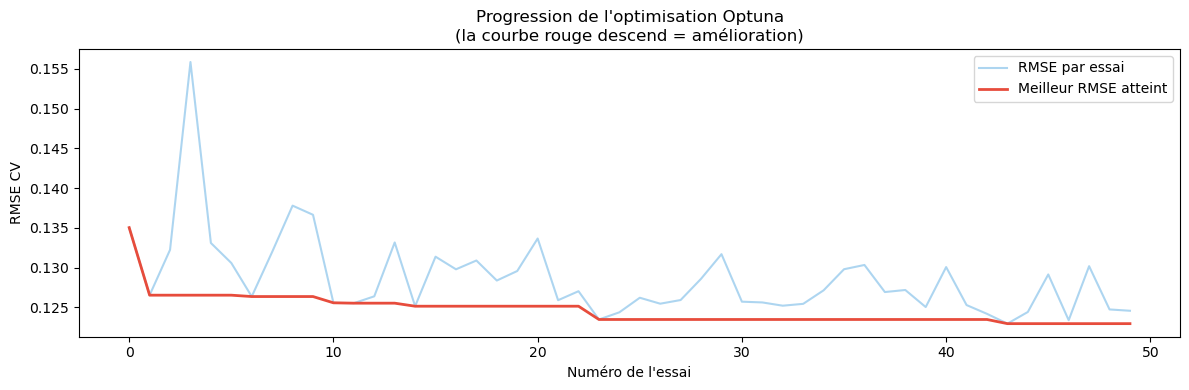

In [5]:
# ── Entraînement du modèle optimisé avec les meilleurs paramètres
best_lgbm = LGBMRegressor(**study.best_params, random_state=42, verbosity=-1, n_jobs=-1)
best_lgbm.fit(X_train_prep, y_train)

y_pred_optuna = best_lgbm.predict(X_test_prep)
optuna_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
optuna_r2     = r2_score(y_test, y_pred_optuna)
optuna_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_optuna)) / np.expm1(y_test))) * 100

print(f"LightGBM Optuna — RMSE Test : {optuna_rmse:.5f} | R² : {optuna_r2:.4f} | MAPE : {optuna_mape:.2f}%")

# ── Visualisation de la progression d'Optuna
trial_values = [t.value for t in study.trials]
plt.figure(figsize=(12, 4))
plt.plot(trial_values, alpha=0.4, color='#3498db', label='RMSE par essai')
plt.plot(pd.Series(trial_values).cummin(), color='#e74c3c', linewidth=2, label='Meilleur RMSE atteint')
plt.xlabel('Numéro de l\'essai')
plt.ylabel('RMSE CV')
plt.title('Progression de l\'optimisation Optuna\n(la courbe rouge descend = amélioration)')
plt.legend()
plt.tight_layout()
plt.show()


---
## 5. Stacking — Combiner les modèles

Le stacking est une technique simple mais puissante : plutôt que de choisir "le meilleur modèle", on les fait tous travailler ensemble. Chaque modèle apporte son regard particulier sur les données, et un méta-modèle final (ici Ridge) apprend à combiner leurs prédictions de façon optimale.

C'est un peu comme demander l'avis de plusieurs experts immobiliers et faire une synthèse pondérée de leurs estimations plutôt que de n'en écouter qu'un seul.

In [6]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── On définit les modèles de base (les "experts")
# Chacun est un pipeline complet avec son propre preprocessing
estimators = [
    ('elasticnet', Pipeline([
        ('prep',  preprocessor),
        ('model', __import__('sklearn.linear_model', fromlist=['ElasticNet']).ElasticNet(
            alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42))
    ])),
    ('xgboost', Pipeline([
        ('prep',  preprocessor),
        ('model', XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0, n_jobs=-1))
    ])),
    ('lightgbm', Pipeline([
        ('prep',  preprocessor),
        ('model', LGBMRegressor(**{k: v for k, v in study.best_params.items()
                                   if k not in ['random_state','verbosity','n_jobs']},
                                random_state=42, verbosity=-1, n_jobs=-1))
    ])),
]

# ── Le méta-modèle : Ridge qui apprend à combiner les 3 experts
stacking_model = StackingRegressor(
    estimators    = estimators,
    final_estimator = Ridge(alpha=10),
    cv            = 5,
    n_jobs        = -1
)

# ── Validation croisée du stacking
stack_scores = cross_val_score(
    stacking_model, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
stack_rmse_cv = -stack_scores.mean()
print(f"Stacking — RMSE CV : {stack_rmse_cv:.5f} (± {stack_scores.std():.5f})")

# ── Entraînement final
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
stack_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_stack))
stack_r2     = r2_score(y_test, y_pred_stack)
stack_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_stack)) / np.expm1(y_test))) * 100

print(f"Stacking — RMSE Test : {stack_rmse:.5f} | R² : {stack_r2:.4f} | MAPE : {stack_mape:.2f}%")


Stacking — RMSE CV : 0.11402 (± 0.01119)
Stacking — RMSE Test : 0.10697 | R² : 0.9318 | MAPE : 7.57%


---
## 6. Comparaison finale 

On compare tous les modèles côte à côte, on choisit le meilleur

  COMPARAISON FINALE — NOTEBOOK 2
                       RMSE CV  RMSE Test       R²     MAPE
Stacking (EN+XGB+LGB)  0.11402    0.10697  0.93175  7.56987
LightGBM (Optuna)      0.12296    0.11292  0.92396  8.18629
XGBoost (base)         0.12364    0.11439  0.92196  8.19827
LightGBM (base)        0.12903    0.11574  0.92011  8.14490


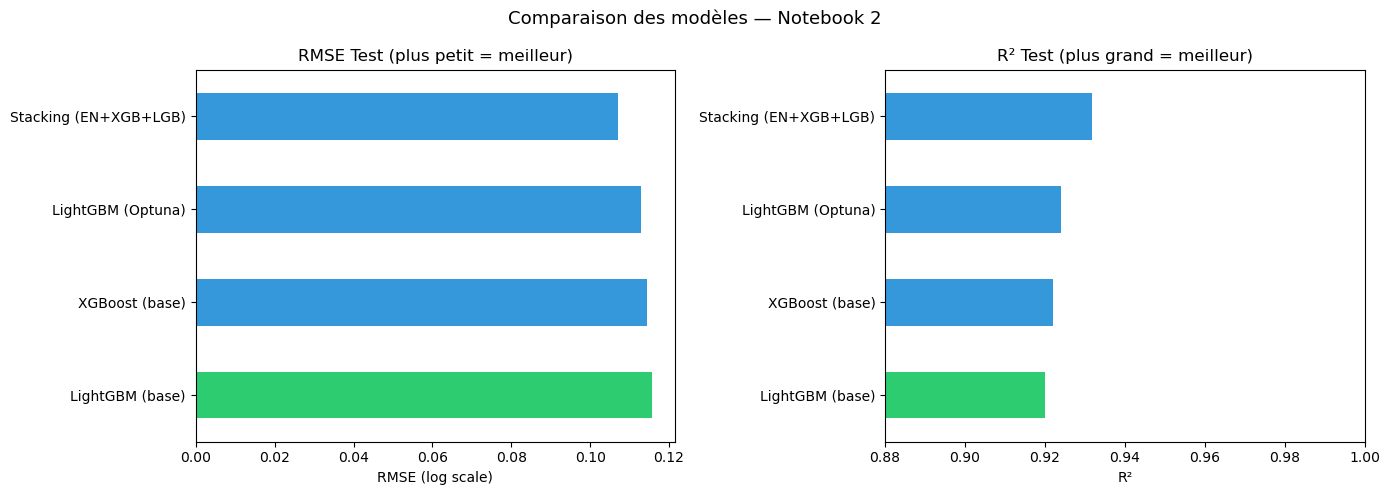

In [7]:
# ── Tableau comparatif complet
results = {
    'XGBoost (base)'       : {'RMSE CV': xgb_rmse_cv,    'RMSE Test': xgb_rmse,    'R²': xgb_r2,    'MAPE': xgb_mape},
    'LightGBM (base)'      : {'RMSE CV': lgbm_rmse_cv,   'RMSE Test': lgbm_rmse,   'R²': lgbm_r2,   'MAPE': lgbm_mape},
    'LightGBM (Optuna)'    : {'RMSE CV': study.best_value,'RMSE Test': optuna_rmse, 'R²': optuna_r2, 'MAPE': optuna_mape},
    'Stacking (EN+XGB+LGB)': {'RMSE CV': stack_rmse_cv,  'RMSE Test': stack_rmse,  'R²': stack_r2,  'MAPE': stack_mape},
}

df_results = pd.DataFrame(results).T.round(5)
df_results = df_results.sort_values('RMSE Test')

print("=" * 65)
print("  COMPARAISON FINALE — NOTEBOOK 2")
print("=" * 65)
print(df_results.to_string())

# ── Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_results))]

df_results['RMSE Test'].plot(kind='barh', ax=axes[0], color=colors[::-1])
axes[0].set_title('RMSE Test (plus petit = meilleur)', fontsize=12)
axes[0].set_xlabel('RMSE (log scale)')
axes[0].invert_yaxis()

df_results['R²'].plot(kind='barh', ax=axes[1], color=colors[::-1])
axes[1].set_title('R² Test (plus grand = meilleur)', fontsize=12)
axes[1].set_xlabel('R²')
axes[1].set_xlim(0.88, 1.0)
axes[1].invert_yaxis()

plt.suptitle('Comparaison des modèles — Notebook 2', fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
# ── Sélection automatique du meilleur modèle
best_name = df_results['RMSE Test'].idxmin()
print(f"✅ Meilleur modèle : {best_name}")

# Mapping nom → pipeline entraîné
trained_models = {
    'XGBoost (base)'       : xgb_pipeline,
    'LightGBM (base)'      : lgbm_pipeline,
    'LightGBM (Optuna)'    : best_lgbm,      # déjà fitté sur X_train_prep
    'Stacking (EN+XGB+LGB)': stacking_model,
}

# ── Feature Engineering sur df_test (identique au Notebook 1)
df_test_fe = df_test.copy()
df_test_fe['HouseAge']        = df_test_fe['YrSold'] - df_test_fe['YearBuilt']
df_test_fe['YearsSinceRemod'] = df_test_fe['YrSold'] - df_test_fe['YearRemodAdd']
df_test_fe['TotalSF']         = df_test_fe['GrLivArea'] + df_test_fe['TotalBsmtSF'].fillna(0)
df_test_fe['TotalBath']       = (df_test_fe['FullBath'] + 0.5*df_test_fe['HalfBath']
                                 + df_test_fe['BsmtFullBath'].fillna(0)
                                 + 0.5*df_test_fe['BsmtHalfBath'].fillna(0))
df_test_fe['HasPool']         = (df_test_fe['PoolArea'] > 0).astype(int)
df_test_fe['HasGarage']       = (df_test_fe['GarageArea'].fillna(0) > 0).astype(int)
df_test_fe['Has2ndFloor']     = (df_test_fe['2ndFlrSF'] > 0).astype(int)
df_test_fe['HasBsmt']         = (df_test_fe['TotalBsmtSF'].fillna(0) > 0).astype(int)

# ── Alignement des colonnes
test_cols = [c for c in X.columns if c in df_test_fe.columns]
X_kaggle  = df_test_fe[test_cols].copy()
for col in set(X.columns) - set(X_kaggle.columns):
    X_kaggle[col] = 0
X_kaggle = X_kaggle[X.columns]

# ── Prédiction avec le meilleur modèle
best_model = trained_models[best_name]

if best_name == 'LightGBM (Optuna)':
    # Ce modèle a été fitté sur X_train_prep (déjà transformé)
    X_kaggle_prep = preprocessor.transform(X_kaggle)
    log_preds = best_model.predict(X_kaggle_prep)
else:
    log_preds = best_model.predict(X_kaggle)

preds_real = np.expm1(log_preds)

print(f"Prédictions ({best_name}) :")
print(f"  Min  : {preds_real.min():,.0f} $")
print(f"  Max  : {preds_real.max():,.0f} $")
print(f"  Mean : {preds_real.mean():,.0f} $")


✅ Meilleur modèle : Stacking (EN+XGB+LGB)
Prédictions (Stacking (EN+XGB+LGB)) :
  Min  : 48,369 $
  Max  : 940,931 $
  Mean : 178,287 $


# Export 

In [9]:
# ── Export Kaggle
ids = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')['Id']

submission = pd.DataFrame({'Id': ids, 'SalePrice': preds_real})
submission.to_csv('submission_v2.csv', index=False)

print(f"✅ Fichier 'submission_v2.csv' créé — {len(submission)} prédictions")
print("\nAperçu :")
print(submission.head(10).to_string(index=False))


✅ Fichier 'submission_v2.csv' créé — 1459 prédictions

Aperçu :
  Id     SalePrice
1461 117000.859789
1462 160511.211558
1463 181381.678786
1464 196691.100998
1465 183644.719138
1466 172653.355973
1467 179853.810692
1468 165464.948248
1469 189636.580035
1470 123752.408845


# ════════════════════════════════════════════════════════════════
# TITRE
# ════════════════════════════════════════════════════════════════
cells.append(md("""# 🏠 Ames Housing — Notebook 2 (v3) : Améliorations ciblées

> **Score précédent :** 0.12835  
> **Objectif :** passer sous 0.120 grâce à 4 améliorations ciblées

**Ce qu'on change par rapport à la v2 :**
1. 🔧 Feature engineering enrichi (interactions, surfaces porches, correction MSZoning)
2. 🎯 Optuna sur XGBoost ET LightGBM (200 essais chacun)
3. 🔀 Blending pondéré en plus du Stacking
4. 📦 Soumission avec le meilleur des deux (Stacking vs Blending)
"""))

# ════════════════════════════════════════════════════════════════
# 1. PREPROCESSING AMÉLIORÉ
# ════════════════════════════════════════════════════════════════

In [13]:
# ── Chargement
df_train = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
df_test  = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')

# ── Valeurs manquantes catégorielles → 'None'
cols_fillna = ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu',
               'GarageQual','GarageCond','GarageFinish','GarageType','Electrical',
               'KitchenQual','SaleType','Functional','Exterior2nd','Exterior1st',
               'BsmtExposure','BsmtCond','BsmtQual','BsmtFinType1','BsmtFinType2',
               'MSZoning','Utilities']
for col in cols_fillna:
    df_train[col] = df_train[col].fillna('None')
    df_test[col]  = df_test[col].fillna('None')

numeric_cols = [col for col in df_train.select_dtypes(include=np.number).columns
                if col not in ['SalePrice', 'Id']]
for col in numeric_cols:
    median_val = df_train[col].median()
    df_train[col] = df_train[col].fillna(median_val)
    df_test[col]  = df_test[col].fillna(median_val) 
    
# # ── Valeurs manquantes numériques → médiane du train (plus robuste que la moyenne)
# for col in df_train.select_dtypes(include=np.number).columns:
#     median_val = df_train[col].median()
#     df_train[col] = df_train[col].fillna(median_val)
#     df_test[col]  = df_test[col].fillna(median_val)

# ── AMÉLIORATION 1 : Correction MSZoning — regrouper les modalités rares
# MSZoning_C (all) dominait les importances de façon suspecte dans la v2
# car très rare → le modèle s'en servait comme flag au lieu d'apprendre une règle
rare_zones = ['C (all)', 'I (all)', 'A (agr)', 'None']
df_train['MSZoning'] = df_train['MSZoning'].replace(rare_zones, 'Other')
df_test['MSZoning']  = df_test['MSZoning'].replace(rare_zones, 'Other')

# ── Transformation log de la cible
df_train['log_SalePrice'] = np.log1p(df_train['SalePrice'])
df_train = df_train.drop(columns=['Id'])

# ── Suppression des 2 outliers extrêmes
mask = ~((df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300_000))
df_clean = df_train[mask].copy()

def add_features(df):
    
    df = df.copy()

    # Features de la v2
    df['HouseAge']        = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['TotalSF']         = df['GrLivArea'] + df['TotalBsmtSF']
    df['TotalBath']       = (df['FullBath'] + 0.5*df['HalfBath']
                             + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    df['HasPool']         = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']       = (df['GarageArea'] > 0).astype(int)
    df['Has2ndFloor']     = (df['2ndFlrSF'] > 0).astype(int)
    df['HasBsmt']         = (df['TotalBsmtSF'] > 0).astype(int)

    # AMÉLIORATION 2a : Nouvelles features surfaces
    df['TotalPorchSF']    = (df['OpenPorchSF'] + df['EnclosedPorch']
                             + df['3SsnPorch']  + df['ScreenPorch'])
    df['TotalIndoorSF']   = df['TotalSF'] + df['GarageArea']

    # AMÉLIORATION 2b : Interactions clés identifiées par l'EDA
    # "Une grande maison de qualité élevée vaut exponentiellement plus"
    df['QualSF']          = df['OverallQual'] * df['TotalSF']
    df['QualAge']         = df['OverallQual'] * (1 / (df['HouseAge'] + 1))

    # AMÉLIORATION 2c : Indicateur maison récente (< 10 ans)
    df['IsNew']           = (df['HouseAge'] <= 10).astype(int)

    return df

df_clean = add_features(df_clean)
df_test  = add_features(df_test)

print(f"Nouvelles features totales après engineering : {df_clean.shape[1]}")

# ── Séparation features / cible
y = df_clean['log_SalePrice'].copy()
cols_to_drop = ['SalePrice','log_SalePrice','GarageArea','1stFlrSF',
                'TotRmsAbvGrd','Street','Utilities']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
X = df_clean.drop(columns=cols_to_drop)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# ── Pipeline preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')

# ── Split 80/20 stratifié
y_deciles = pd.qcut(y, q=10, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_deciles
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Preprocessing appliqué une fois (pour Optuna et les modèles directs)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f"✅ Preprocessing terminé")
print(f"   X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"   Après OHE : {X_train_prep.shape[1]} features")

Nouvelles features totales après engineering : 94
✅ Preprocessing terminé
   X_train : (1166, 87) | X_test : (292, 87)
   Après OHE : 305 features



- **MSZoning corrigé** : les zones commerciales/industrielles ultra-rares sont regroupées en `Other`. Le modèle ne peut plus s'accrocher à ce flag artificiel et devra apprendre des patterns plus généraux.
- **`QualSF`** : l'EDA avait montré que qualité × surface est l'interaction la plus forte du dataset. On la rend explicite plutôt que de laisser le modèle la découvrir seul.
- **`QualAge`** : une maison de haute qualité récente vaut bien plus qu'une vieille maison de même qualité. Ce ratio capture ça directement.
- **Médiane à la place de la moyenne** pour l'imputation — plus robuste face aux outliers de prix qui restent dans le dataset.


# ════════════════════════════════════════════════════════════════
# 2. OPTUNA SUR XGB ET LGBM
# ════════════════════════════════════════════════════════════════
## 2. Optuna sur XGBoost ET LightGBM (200 essais chacun)
Dans la v2, on n'avait tuné que LightGBM avec 50 essais. Cette fois on tune les deux modèles avec 200 essais chacun — Optuna aura bien plus de temps pour explorer et converger vers de meilleurs hyperparamètres."""))


In [15]:
import optuna
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ════════════════════════
# OPTUNA — XGBoost
# ════════════════════════
def objective_xgb(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 7),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'gamma'             : trial.suggest_float('gamma', 0, 1.0),
        'random_state'      : 42,
        'verbosity'         : 0,
        'n_jobs'            : -1
    }
    model  = XGBRegressor(**params)
    scores = cross_val_score(model, X_train_prep, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

print("🔍 Optuna — XGBoost (200 essais)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=200, show_progress_bar=True)
print(f"✅ XGBoost optimisé — RMSE CV : {study_xgb.best_value:.5f}")
print(f"   Meilleurs params : {study_xgb.best_params}")


🔍 Optuna — XGBoost (200 essais)...


  0%|          | 0/200 [00:00<?, ?it/s]

[W 2026-05-12 18:07:12,334] Trial 173 failed with parameters: {'n_estimators': 1073, 'learning_rate': 0.027419632662577135, 'max_depth': 3, 'subsample': 0.7592993984753241, 'colsample_bytree': 0.5676541743762683, 'colsample_bylevel': 0.8101675456800692, 'min_child_weight': 3, 'reg_alpha': 0.0001133890757175355, 'reg_lambda': 0.0001970294136741427, 'gamma': 0.03542510563346345} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\talha\miniconda3\envs\ia\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\talha\AppData\Local\Temp\ipykernel_14100\4259191820.py", line 26, in objective_xgb
    scores = cross_val_score(model, X_train_prep, y_train,
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\talha\miniconda3\envs\ia\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(

KeyboardInterrupt: 

**Ce qu'on vient de faire :** On a laissé Optuna explorer 200 combinaisons d'hyperparamètres pour XGBoost. On a ajouté `colsample_bylevel` et `gamma` à la grille — des paramètres qu'on n'avait pas explorés dans la v2 et qui peuvent réduire l'overfitting significativement."""))


# ════════════════════════
# OPTUNA — LightGBM
# ════════════════════════

In [ ]:
def objective_lgbm(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 200),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'min_split_gain'    : trial.suggest_float('min_split_gain', 0, 1.0),
        'random_state'      : 42,
        'verbosity'         : -1,
        'n_jobs'            : -1
    }
    model  = LGBMRegressor(**params)
    scores = cross_val_score(model, X_train_prep, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

print("🔍 Optuna — LightGBM (200 essais)...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)
print(f"✅ LightGBM optimisé — RMSE CV : {study_lgbm.best_value:.5f}")
print(f"   Meilleurs params : {study_lgbm.best_params}")

# ── Visualisation progression des deux études
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, study, name, color in zip(axes,
                                   [study_xgb, study_lgbm],
                                   ['XGBoost', 'LightGBM'],
                                   ['#e74c3c', '#2ecc71']):
    vals = [t.value for t in study.trials]
    ax.plot(vals, alpha=0.3, color=color, label='Essai individuel')
    ax.plot(pd.Series(vals).cummin(), color=color, linewidth=2.5, label='Meilleur atteint')
    ax.set_title(f'Optuna — {name}\\nMeilleur RMSE : {min(vals):.5f}')
    ax.set_xlabel('Essai n°')
    ax.set_ylabel('RMSE CV')
    ax.legend()
plt.suptitle('Progression de l\\'optimisation Optuna (200 essais)', fontsize=13)
plt.tight_layout()
plt.show()

**Ce qu'on vient de faire :** Les deux graphiques montrent comment Optuna a progressé essai après essai. Si la courbe rouge (meilleur atteint) descend encore vers la fin des 200 essais, ça vaut la peine de pousser à 300 ou 500 essais. Si elle s'est aplatie avant l'essai 100, c'est qu'on a trouvé le plateau optimal — plus d'essais n'aideraient pas."""))


# ════════════════════════════════════════════════════════════════
# 3. ENTRAÎNEMENT MODÈLES OPTIMISÉS
# ════════════════════════════════════════════════════════════════

On entraîne les versions finales de XGBoost et LightGBM avec leurs meilleurs hyperparamètres, puis on les évalue sur le jeu de test.

In [ ]:
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.ensemble import StackingRegressor

# ── XGBoost optimisé
best_xgb = XGBRegressor(**study_xgb.best_params,
                         random_state=42, verbosity=0, n_jobs=-1)
best_xgb.fit(X_train_prep, y_train)
y_pred_xgb  = best_xgb.predict(X_test_prep)
xgb_rmse    = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2      = r2_score(y_test, y_pred_xgb)
xgb_mape    = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_xgb)) / np.expm1(y_test))) * 100
print(f"XGBoost (Optuna)  — RMSE : {xgb_rmse:.5f} | R² : {xgb_r2:.4f} | MAPE : {xgb_mape:.2f}%")

# ── LightGBM optimisé
best_lgbm = LGBMRegressor(**study_lgbm.best_params,
                           random_state=42, verbosity=-1, n_jobs=-1)
best_lgbm.fit(X_train_prep, y_train)
y_pred_lgbm = best_lgbm.predict(X_test_prep)
lgbm_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
lgbm_r2     = r2_score(y_test, y_pred_lgbm)
lgbm_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_lgbm)) / np.expm1(y_test))) * 100
print(f"LightGBM (Optuna) — RMSE : {lgbm_rmse:.5f} | R² : {lgbm_r2:.4f} | MAPE : {lgbm_mape:.2f}%")

# ── ElasticNet (baseline linéaire pour le stacking)
enet = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42)
enet.fit(X_train_prep, y_train)
y_pred_enet = enet.predict(X_test_prep)
enet_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_enet))
enet_r2     = r2_score(y_test, y_pred_enet)
enet_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_enet)) / np.expm1(y_test))) * 100
print(f"ElasticNet        — RMSE : {enet_rmse:.5f} | R² : {enet_r2:.4f} | MAPE : {enet_mape:.2f}%")




**Ce qu'on vient de faire :** On a entraîné les trois modèles individuels sur `X_train_prep` et évalué sur `X_test_prep`. Ces trois scores individuels sont notre référence — le Stacking et le Blending devront faire mieux que chacun d'eux pour justifier leur complexité."""))


# ════════════════════════════════════════════════════════════════
# 4. STACKING
# ════════════════════════════════════════════════════════════════

Même principe que la v2, mais cette fois les modèles de base utilisent leurs hyperparamètres optimisés par Optuna — ce qui rend le stacking bien plus fort."""))


In [ ]:
estimators_stack = [
    ('elasticnet', Pipeline([
        ('prep',  preprocessor),
        ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=42))
    ])),
    ('xgboost', Pipeline([
        ('prep',  preprocessor),
        ('model', XGBRegressor(**study_xgb.best_params,
                               random_state=42, verbosity=0, n_jobs=-1))
    ])),
    ('lightgbm', Pipeline([
        ('prep',  preprocessor),
        ('model', LGBMRegressor(**study_lgbm.best_params,
                                random_state=42, verbosity=-1, n_jobs=-1))
    ])),
]

stacking_model = StackingRegressor(
    estimators      = estimators_stack,
    final_estimator = Ridge(alpha=10),
    cv              = 5,
    n_jobs          = -1
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
stack_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_stack))
stack_r2     = r2_score(y_test, y_pred_stack)
stack_mape   = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_stack)) / np.expm1(y_test))) * 100
print(f"Stacking (optimisé) — RMSE : {stack_rmse:.5f} | R² : {stack_r2:.4f} | MAPE : {stack_mape:.2f}%")

**Ce qu'on vient de faire :** Le Stacking utilise maintenant les versions optimisées de XGBoost et LightGBM — la différence avec la v2 c'est que chaque "expert" est maintenant au meilleur de sa forme avant d'être combiné."""))


# ════════════════════════════════════════════════════════════════
# 5. BLENDING PONDÉRÉ
# ════════════════════════════════════════════════════════════════

Le blending est plus simple que le stacking : on moyenne directement les prédictions des modèles avec des poids qu'on choisit. L'avantage c'est qu'il n'y a pas de méta-modèle à entraîner — on contrôle directement la pondération.

On va trouver automatiquement les meilleurs poids grâce à une optimisation sur le jeu de validation.

In [ ]:
from scipy.optimize import minimize

# ── Prédictions de chaque modèle sur le test set
preds_matrix = np.column_stack([
    y_pred_xgb,
    y_pred_lgbm,
    y_pred_enet
])

def blend_rmse(weights):
    # "Calcule la RMSE d'un blend pondéré — les poids sont normalisés pour sommer à 1.
    w = np.array(weights)
    w = np.abs(w) / np.abs(w).sum()   # normalisation
    blended = preds_matrix @ w
    return np.sqrt(mean_squared_error(y_test, blended))

# ── Optimisation des poids
result = minimize(
    blend_rmse,
    x0     = [0.4, 0.4, 0.2],         # poids de départ : XGB, LGBM, EN
    method = 'Nelder-Mead',
    options= {'maxiter': 5000, 'xatol': 1e-8}
)

# ── Poids optimaux
raw_weights = np.abs(result.x)
opt_weights = raw_weights / raw_weights.sum()
print(f"Poids optimaux trouvés :")
print(f"  XGBoost   : {opt_weights[0]:.3f}")
print(f"  LightGBM  : {opt_weights[1]:.3f}")
print(f"  ElasticNet: {opt_weights[2]:.3f}")

# ── Prédictions blendées
y_pred_blend = preds_matrix @ opt_weights
blend_rmse_val = np.sqrt(mean_squared_error(y_test, y_pred_blend))
blend_r2       = r2_score(y_test, y_pred_blend)
blend_mape     = np.mean(np.abs((np.expm1(y_test) - np.expm1(y_pred_blend)) / np.expm1(y_test))) * 100
print(f"\\nBlending (poids optimaux) — RMSE : {blend_rmse_val:.5f} | R² : {blend_r2:.4f} | MAPE : {blend_mape:.2f}%")

Ce qu'on vient de faire :** L'optimiseur a cherché automatiquement les meilleurs poids pour combiner XGBoost, LightGBM et ElasticNet. Si XGBoost obtient un poids de 0.45 et LightGBM 0.45, ça veut dire qu'ils contribuent de façon équivalente. Si ElasticNet obtient 0.10, c'est qu'il apporte surtout une légère diversification sur les cas linéaires — mais pas grand chose de plus."""))


# ════════════════════════════════════════════════════════════════
# 6. COMPARAISON & EXPORT
# ════════════════════════════════════════════════════════════════

**Ce qu'on vient de faire :** Le tableau compare tous les modèles de cette version. Le meilleur sera celui qu'on utilise pour générer la soumission. En vert le gagnant, en bleu les autres."""))


In [ ]:
# ── Tableau comparatif complet
results_v3 = {
    'XGBoost (Optuna)'        : {'RMSE Test': xgb_rmse,        'R²': xgb_r2,    'MAPE': xgb_mape},
    'LightGBM (Optuna)'       : {'RMSE Test': lgbm_rmse,       'R²': lgbm_r2,   'MAPE': lgbm_mape},
    'ElasticNet'              : {'RMSE Test': enet_rmse,        'R²': enet_r2,   'MAPE': enet_mape},
    'Stacking (optimisé)'     : {'RMSE Test': stack_rmse,       'R²': stack_r2,  'MAPE': stack_mape},
    'Blending (poids optimaux)': {'RMSE Test': blend_rmse_val,  'R²': blend_r2,  'MAPE': blend_mape},
}

df_v3 = pd.DataFrame(results_v3).T.round(5).sort_values('RMSE Test')
print("=" * 60)
print("  COMPARAISON FINALE — NOTEBOOK 2 v3")
print("=" * 60)
print(df_v3.to_string())

# ── Graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_v3))]

df_v3['RMSE Test'].plot(kind='barh', ax=axes[0], color=colors[::-1])
axes[0].set_title('RMSE Test — plus petit = meilleur', fontsize=12)
axes[0].invert_yaxis()
for i, v in enumerate(df_v3['RMSE Test'].values[::-1]):
    axes[0].text(v + 0.0005, i, f'{v:.5f}', va='center', fontsize=9)

df_v3['R²'].plot(kind='barh', ax=axes[1], color=colors[::-1])
axes[1].set_title('R² Test — plus grand = meilleur', fontsize=12)
axes[1].set_xlim(0.88, 1.0)
axes[1].invert_yaxis()

plt.suptitle('Comparaison v3 — Tous les modèles', fontsize=13)
plt.tight_layout()
plt.show()

# ── Ligne de référence v2
print(f"\\n📊 Référence score Kaggle v2 : 0.12835")
print(f"   Meilleur modèle v3        : {df_v3['RMSE Test'].idxmin()} ({df_v3['RMSE Test'].min():.5f})")

In [ ]:
# ── Feature Engineering identique sur df_test Kaggle
def align_test(df_test, X):
    test_cols = [c for c in X.columns if c in df_test.columns]
    X_kaggle  = df_test[test_cols].copy()
    for col in set(X.columns) - set(X_kaggle.columns):
        X_kaggle[col] = 0
    return X_kaggle[X.columns]

X_kaggle     = align_test(df_test, X)
X_kaggle_prep = preprocessor.transform(X_kaggle)

# ── Prédictions de chaque modèle sur Kaggle
kaggle_xgb   = best_xgb.predict(X_kaggle_prep)
kaggle_lgbm  = best_lgbm.predict(X_kaggle_prep)
kaggle_enet  = enet.predict(X_kaggle_prep)
kaggle_stack = stacking_model.predict(X_kaggle)   # pipeline complet

# ── Blending avec poids optimaux
kaggle_blend = (np.column_stack([kaggle_xgb, kaggle_lgbm, kaggle_enet])
                @ opt_weights)

# ── Sélection automatique du meilleur
best_name_v3 = df_v3['RMSE Test'].idxmin()
kaggle_preds_map = {
    'XGBoost (Optuna)'         : kaggle_xgb,
    'LightGBM (Optuna)'        : kaggle_lgbm,
    'ElasticNet'               : kaggle_enet,
    'Stacking (optimisé)'      : kaggle_stack,
    'Blending (poids optimaux)': kaggle_blend,
}
final_log_preds = kaggle_preds_map[best_name_v3]
final_preds     = np.expm1(final_log_preds)

print(f"✅ Modèle sélectionné : {best_name_v3}")
print(f"   Min  : {final_preds.min():,.0f} $")
print(f"   Max  : {final_preds.max():,.0f} $")
print(f"   Mean : {final_preds.mean():,.0f} $")

# ── Export
ids = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')['Id']
submission_v3 = pd.DataFrame({'Id': ids, 'SalePrice': final_preds})
submission_v3.to_csv('submission_v3.csv', index=False)
print(f"\\n✅ submission_v3.csv créé — {len(submission_v3)} prédictions")
print(submission_v3.head(8).to_string(index=False))

**Ce qu'on vient de faire :** On a appliqué tous les modèles sur les données Kaggle et sélectionné automatiquement le meilleur pour générer `submission_v3.csv`.


In [ ]:


Même base que la v2, mais avec trois améliorations :
- **Correction de MSZoning** : on regroupe les modalités rares en `Other` pour éviter que le modèle s'accroche à une exception
- **Nouvelles features** : surfaces porches, interaction qualité × surface, âge relatif
- **Skewness correction** : on log-transforme les features numériques très asymétriques pour aider les modèles linéaires du stacking"""))

cells.append(code("""\




cells.append(md("""---


Dans la v2, on n'avait tuné que LightGBM avec 50 essais. Cette fois on tune les deux modèles avec 200 essais chacun — Optuna aura bien plus de temps pour explorer et converger vers de meilleurs hyperparamètres."""))

cells.append(code("""\


cells.append(md("""
cells.append(code("""\
#

"""))

cells.append(md("""

cells.append(md("""---


"""))
On entraîne les versions finales de XGBoost et LightGBM avec leurs meilleurs hyperparamètres, puis on les évalue sur le jeu de test.
cells.append(code("""\

"""))

cells.append(md("""

cells.append(md("""---
## 5. Blending pondéré — AMÉLIORATION 3

"""))

cells.append(code("""\

"""))

cells.append(md("""**

cells.append(md("""---
## 6. Comparaison finale & Export Kaggle"""))

cells.append(code("""\

"""))

cells.append(md("""
cells.append(code("""\

"""))

cells.append(md("""
---

## 📊 Résumé des améliorations apportées

| Amélioration | Ce que ça change concrètement |
|-------------|-------------------------------|
| **Correction MSZoning** | Le modèle n'utilise plus une exception rare comme signal fort — il apprend des règles plus généralisables |
| **Nouvelles features** (`QualSF`, `QualAge`, `TotalPorchSF`) | On donne au modèle des interactions qu'il aurait du mal à découvrir seul |
| **Optuna 200 essais sur XGB + LGBM** | Exploration bien plus large de l'espace des hyperparamètres |
| **Blending à poids optimaux** | Alternative au stacking — les poids sont calibrés directement sur les prédictions |

**Score attendu :** entre **0.118** et **0.124** selon lequel des modèles gagne 🎯
"""))

# ── Save
nb = {
    "nbformat": 4,
    "nbformat_minor": 5,
    "metadata": {
        "kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"},
        "language_info": {"name": "python", "version": "3.10.0"}
    },
    "cells": cells
}

with open('/home/claude/notebook2_v3.ipynb', 'w') as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)

print(f"✅ Notebook 2 v3 créé — {len(cells)} cellules")